In [ ]:

"""
통신 서비스 고객 이탈 예측 분석
Telco Customer Churn Analysis

작성자: 원종성
날짜: 2025-12-24

분석 순서:
1. 데이터 로딩 및 기본 확인
2. 상관관계 분석 (Heatmap)
3. 결측치 처리
4. 데이터 전처리
5. 전처리 후 상관관계 재확인
"""

'\n통신 서비스 고객 이탈 예측 분석\nTelco Customer Churn Analysis\n\n작성자: 원종성\n날짜: 2025-12-24\n'

In [2]:
# 사전 설치: pip install pandas numpy matplotlib seaborn scikit-learn
# =============================================================================
# 0. 라이브러리 임포트
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Pandas 출력 옵션
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)

In [3]:
# =============================================================================
# 1. 데이터 로딩 및 기본 확인
# =============================================================================
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv', encoding="utf-8")

print(f"데이터 로딩 완료")
print(f"  - 데이터 형태: {df.shape[0]:,}행 × {df.shape[1]}열")

print(f"\n컬럼 정보 요약:")
print(f"{'번호':>4} {'컬럼명':<25} {'타입':<10} {'고유값':>6} {'결측치':>6}")
print("-" * 60)
for idx, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    unique = df[col].nunique()
    missing = df[col].isnull().sum()
    print(f"{idx:4d} {col:<25} {dtype:<10} {unique:6d} {missing:6d}")

데이터 로딩 완료
  - 데이터 형태: 7,043행 × 21열

컬럼 정보 요약:
  번호 컬럼명                       타입            고유값    결측치
------------------------------------------------------------
   1 customerID                object       7043      0
   2 gender                    object          2      0
   3 SeniorCitizen             int64           2      0
   4 Partner                   object          2      0
   5 Dependents                object          2      0
   6 tenure                    int64          73      0
   7 PhoneService              object          2      0
   8 MultipleLines             object          3      0
   9 InternetService           object          3      0
  10 OnlineSecurity            object          3      0
  11 OnlineBackup              object          3      0
  12 DeviceProtection          object          3      0
  13 TechSupport               object          3      0
  14 StreamingTV               object          3      0
  15 StreamingMovies           object          3     

In [4]:
# 샘플 데이터
print(f"\n데이터 샘플:")
print(df.head())


데이터 샘플:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          N

In [5]:
# =============================================================================
# 2. 상관관계 분석 (Heatmap)
# =============================================================================

# 2-1. 데이터 복사 및 전처리
df_corr = df.copy()

# TotalCharges를 숫자로 변환
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

# 타겟 변수 변환
df_corr['Churn'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})

# 이진 변수 변환
binary_mappings = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_mappings.items():
    df_corr[col] = df_corr[col].map(mapping)

# 다중 범주형 변수는 레이블 인코딩
from sklearn.preprocessing import LabelEncoder
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

le = LabelEncoder()
for col in categorical_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# customerID 제거('모든 행에서 개별적이므로 제거')
df_corr = df_corr.drop('customerID', axis=1)

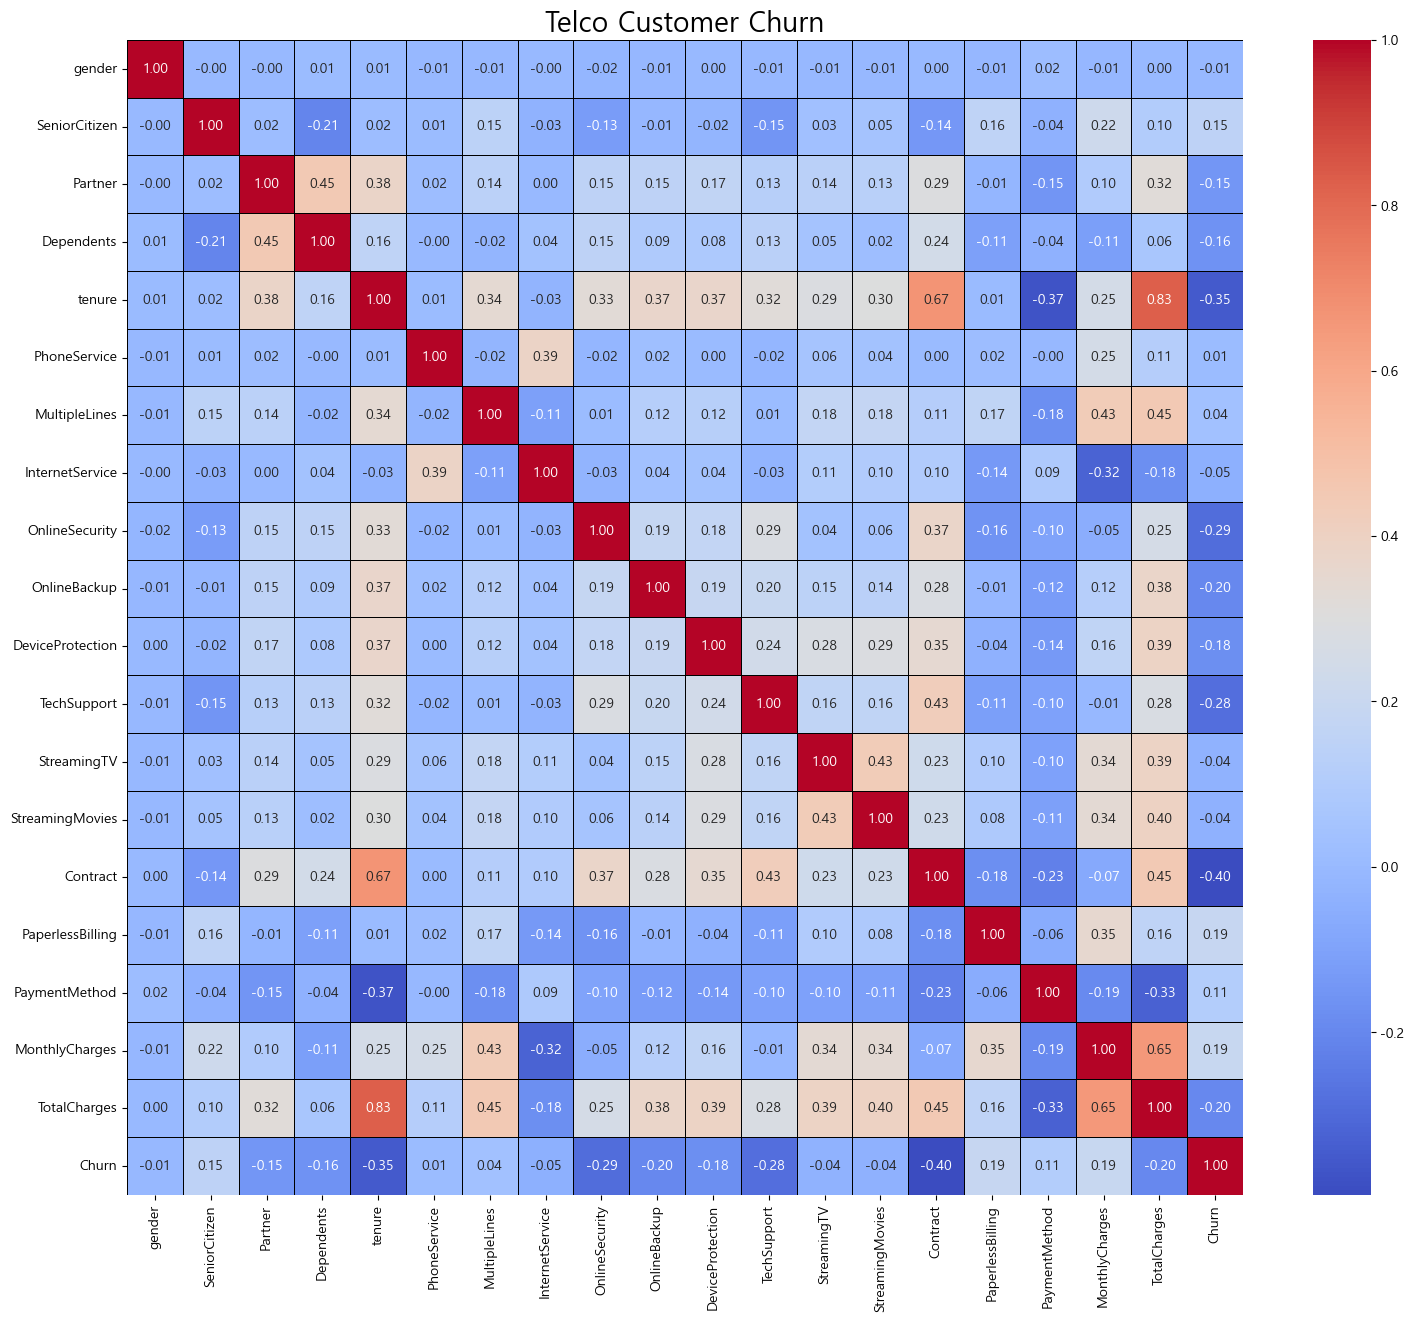

In [6]:
# 2-2. 상관관계 행렬 계산
correlation_matrix = df_corr.corr()

# 2-3. Heatmap 시각화
# 그래프 크기 설정
plt.figure(figsize=(18, 15)) # 변수의 개수가 많으므로 크기를 키워서 가독성을 높입니다.

# 히트맵 생성 및 출력
sns.heatmap(
    correlation_matrix,
    annot=True, # 각 셀에 상관계수 값 표시
    fmt='.2f', # 소수점 둘째 자리까지 표시
    cmap='coolwarm', # 색상 팔레트 설정 (음의 상관관계: 파랑, 양의 상관관계: 빨강)
    cbar=True, # 컬러바 표시
    linewidths=.5, # 셀 경계선 설정
    linecolor='black'
)

plt.title('Telco Customer Churn', fontsize=20)
plt.show()

In [7]:
# =============================================================================
# 3. 탐색적 데이터 분석
# =============================================================================

# 3-1. 컬럼 선택 및 제거 (최종 사용 컬럼 기반)

# 최종적으로 사용할 컬럼 리스트 정의
target_col = ['Churn']
numeric_cols = ['tenure', 'MonthlyCharges']
categorical_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'StreamingTV', 'StreamingMovies', 'SeniorCitizen', 'Partner',
    'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]
final_columns = target_col + numeric_cols + categorical_cols

# 선택된 컬럼만 남기기
df_processed = df[final_columns].copy()

print("="*40)
print("[1단계: 최종 컬럼 선택 완료]")
print("="*40)
print(f"선택된 컬럼 개수: {df_processed.shape[1]}개")
print(f"선택된 컬럼 목록:\n{df_processed.columns.tolist()}")

[1단계: 최종 컬럼 선택 완료]
선택된 컬럼 개수: 15개
선택된 컬럼 목록:
['Churn', 'tenure', 'MonthlyCharges', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
# 3-2. 결측치 및 중복값 통계 (재확인)

# 수치형 변수 히스토그램(Histogram)

print("\n[결측치 분석]")
missing_data = df_processed.isnull().sum()
missing_data = missing_data[missing_data > 0]

if len(missing_data) > 0:
    print(f"결측치가 있는 컬럼:")
    for col, count in missing_data.items():
        print(f"  - {col}: {count}개 ({count/len(df_processed)*100:.2f}%)")
else:
    print("TotalCharges 제거로 인해 현재 데이터에는 결측치 없음")

# 3-3. 범주형 변수 인코딩

# 1) 타겟 변수 인코딩

print("\n[1. 타겟 변수(Churn) 인코딩]")

df_processed['Churn'] = df_processed['Churn'].map({'No': 0, 'Yes': 1})

print(f" - Churn: No(0), Yes(1)로 변환")


# 2) 이진/순서형 변수 인코딩
print("\n[2. 이진/순서형 변수 인코딩]")
# 이진 변수 (Yes/No)
binary_yn_cols = ['Partner', 'Dependents', 'PaperlessBilling',
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'StreamingTV', 'StreamingMovies'] # 서비스 관련 Yes/No도 포함
binary_mapping = {'No': 0, 'Yes': 1, 'No internet service': 0, 'No phone service': 0}

# Note: 'No internet service'는 서비스 가입 안 한 경우로 0으로 간주

for col in binary_yn_cols:
    if col in df_processed.columns:
        # SeniorCitizen은 이미 0/1이므로 제외, gender/PhoneService는 제거됨
        # .str accessor를 사용하여 안전하게 map 적용
        df_processed[col] = df_processed[col].astype(str).str.strip().map(binary_mapping).fillna(df_processed[col])
        print(f"  - {col}: Yes(1), No(0) 계열로 변환")

# SeniorCitizen: 이미 int/float 형태이므로 별도 처리 불필요

df_processed['SeniorCitizen'] = pd.to_numeric(df_processed['SeniorCitizen'], errors='coerce').astype('int')

print(f"  - SeniorCitizen: 데이터 타입 정제 완료 (0 또는 1)")

# 3-3. 순서형 변수 인코딩

print("\n[3-3. 순서형 변수 인코딩]")

df_processed['Contract'] = df_processed['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

print("  - Contract: Month-to-month(0), One year(1), Two year(2)로 변환")


[결측치 분석]
TotalCharges 제거로 인해 현재 데이터에는 결측치 없음

[1. 타겟 변수(Churn) 인코딩]
 - Churn: No(0), Yes(1)로 변환

[2. 이진/순서형 변수 인코딩]
  - Partner: Yes(1), No(0) 계열로 변환
  - Dependents: Yes(1), No(0) 계열로 변환
  - PaperlessBilling: Yes(1), No(0) 계열로 변환
  - OnlineSecurity: Yes(1), No(0) 계열로 변환
  - OnlineBackup: Yes(1), No(0) 계열로 변환
  - DeviceProtection: Yes(1), No(0) 계열로 변환
  - StreamingTV: Yes(1), No(0) 계열로 변환
  - StreamingMovies: Yes(1), No(0) 계열로 변환
  - SeniorCitizen: 데이터 타입 정제 완료 (0 또는 1)

[3-3. 순서형 변수 인코딩]
  - Contract: Month-to-month(0), One year(1), Two year(2)로 변환


In [9]:
# 3-4. 명목 범주형 변수 One-Hot Encoding

print("\n[3-4. 명목 범주형 변수 One-Hot Encoding]")
nominal_cols_to_ohe = ['InternetService', 'PaymentMethod']

# pd.get_dummies로 OHE 적용. drop_first=True로 다중공선성 방지

original_shape = df_processed.shape[1]

df_processed = pd.get_dummies(df_processed, columns=nominal_cols_to_ohe, drop_first=True)

print(f"  - {len(nominal_cols_to_ohe)}개 컬럼 → {df_processed.shape[1] - original_shape + len(nominal_cols_to_ohe)}개 컬럼으로 확장")


# 3-5. 수치형 변수 스케일링
print("\n[수치형 변수 스케일링 (StandardScaler)]")

scaler = StandardScaler()

# 선택된 수치형 변수만 스케일링

df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])

print(f"  - {numeric_cols} 표준화 완료")

# Scaler 저장
with open('model/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("\n[StandardScaler 저장 완료]")
print("  - 파일명: model/scaler.pkl")
print(f"  - 스케일링 대상 변수: {numeric_cols}")
print(f"  - 저장된 평균값: {scaler.mean_}")
print(f"  - 저장된 표준편차: {scaler.scale_}")
print("="*40)

# 3-6. 전처리 완료 정보 및 X, y 분리

print("="*30)
print("[전처리 완료]")
print("="*30)
print(f"전처리 후 데이터 형태: {df_processed.shape}")
print(f"전처리 후 최종 컬럼 개수: {df_processed.shape[1]}개")
print(f"전처리 후 결측치 개수: {df_processed.isnull().sum().sum()}")
print("\n[전처리 후 데이터 샘플]")
print(df_processed.head())


# 전처리 후 데이터 타입 확인

print("\n[전처리 후 컬럼별 데이터 타입]")
print(f"{'컬럼명':<30} {'타입':<10} {'고유값':>6}")
print("-" * 50)

for col in df_processed.columns:
    dtype = str(df_processed[col].dtype)
    unique = df_processed[col].nunique()
    print(f"{col:<30} {dtype:<10} {unique:6d}")

# 종속 변수 (y) 정의: 'Churn' 컬럼
y = df_processed['Churn']

# 독립 변수 (X) 정의: 'Churn' 컬럼을 제외한 모든 컬럼
X = df_processed.drop('Churn', axis=1)

print("="*30)
print("[전처리 최종 완료: X, y 분리]")
print(f"X (독립 변수) 개수: {X.shape[1]}개")
print(f"y (종속 변수) 컬럼명: Churn")
print("="*30)


[3-4. 명목 범주형 변수 One-Hot Encoding]
  - 2개 컬럼 → 5개 컬럼으로 확장

[수치형 변수 스케일링 (StandardScaler)]
  - ['tenure', 'MonthlyCharges'] 표준화 완료

[StandardScaler 저장 완료]
  - 파일명: model/scaler.pkl
  - 스케일링 대상 변수: ['tenure', 'MonthlyCharges']
  - 저장된 평균값: [32.37114866 64.76169246]
  - 저장된 표준편차: [24.55773742 30.08791085]
[전처리 완료]
전처리 후 데이터 형태: (7043, 18)
전처리 후 최종 컬럼 개수: 18개
전처리 후 결측치 개수: 0

[전처리 후 데이터 샘플]
   Churn    tenure  MonthlyCharges  OnlineSecurity  OnlineBackup  \
0      0 -1.277445       -1.160323               0             1   
1      0  0.066327       -0.259629               1             0   
2      1 -1.236724       -0.362660               1             1   
3      0  0.514251       -0.746535               1             0   
4      1 -1.236724        0.197365               0             0   

   DeviceProtection  StreamingTV  StreamingMovies  SeniorCitizen  Partner  \
0                 0            0                0              0        1   
1                 1            0               


타겟 변수 (Churn) 분포 시각화


C:\Users\human-18\AppData\Local\Temp\ipykernel_984\607413024.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


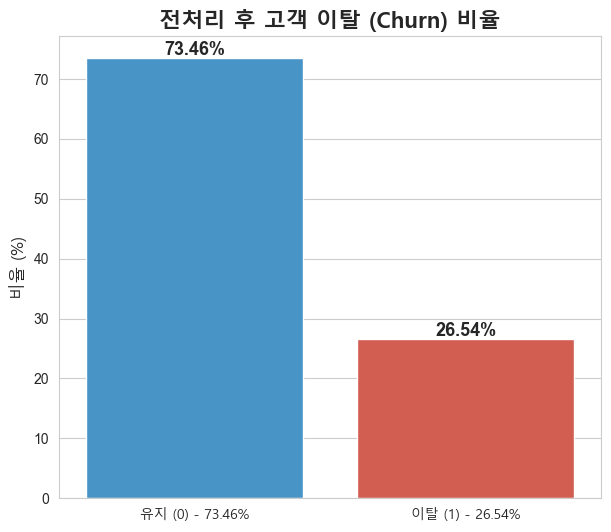


✓ 타겟 변수 Churn의 불균형을 시각적으로 확인했습니다. 이탈(1) 비율이 약 26.6%로 불균형 상태입니다.


In [10]:
#  3.7 전처리 시각화
# 1) 타겟 변수 (Churn) 분포 확인

sns.set_style("whitegrid")
print("\n타겟 변수 (Churn) 분포 시각화")

plt.figure(figsize=(7, 6))
# df_processed는 최종 전처리된 데이터프레임
churn_counts = df_processed['Churn'].value_counts(normalize=True) * 100

# 막대 그래프 생성
ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    order=[0, 1],   # '0', '1' 순서대로 정렬하여 시각화 (유지, 이탈)
    palette=['#3498db', '#e74c3c'] # 유지:파랑, 이탈:빨강 계열 색상
)

plt.title('전처리 후 고객 이탈 (Churn) 비율', font = 'Malgun Gothic', fontsize=16, fontweight='bold')
plt.xticks([0, 1], ['유지 (0) - {:.2f}%'.format(churn_counts.iloc[0]),
                    '이탈 (1) - {:.2f}%'.format(churn_counts.iloc[1])],
           fontsize=12, font = 'Malgun Gothic')
plt.ylabel('비율 (%)', font = 'Malgun Gothic', fontsize=12)
plt.xlabel('') # x축 라벨 제거

# 각 막대 위에 비율 텍스트 추가
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.5,
            f'{height:.2f}%',
            ha='center', fontsize=13, fontweight='bold')
    
plt.show()
print("\n✓ 타겟 변수 Churn의 불균형을 시각적으로 확인했습니다. 이탈(1) 비율이 약 26.6%로 불균형 상태입니다.")


주요 수치형 변수 분포 시각화 (스케일링 후)


C:\Users\human-18\AppData\Local\Temp\ipykernel_984\1933191911.py:21: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 타이틀 공간 확보
C:\Users\human-18\AppData\Local\Temp\ipykernel_984\1933191911.py:21: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 타이틀 공간 확보
c:\ydataprofile\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ydataprofile\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


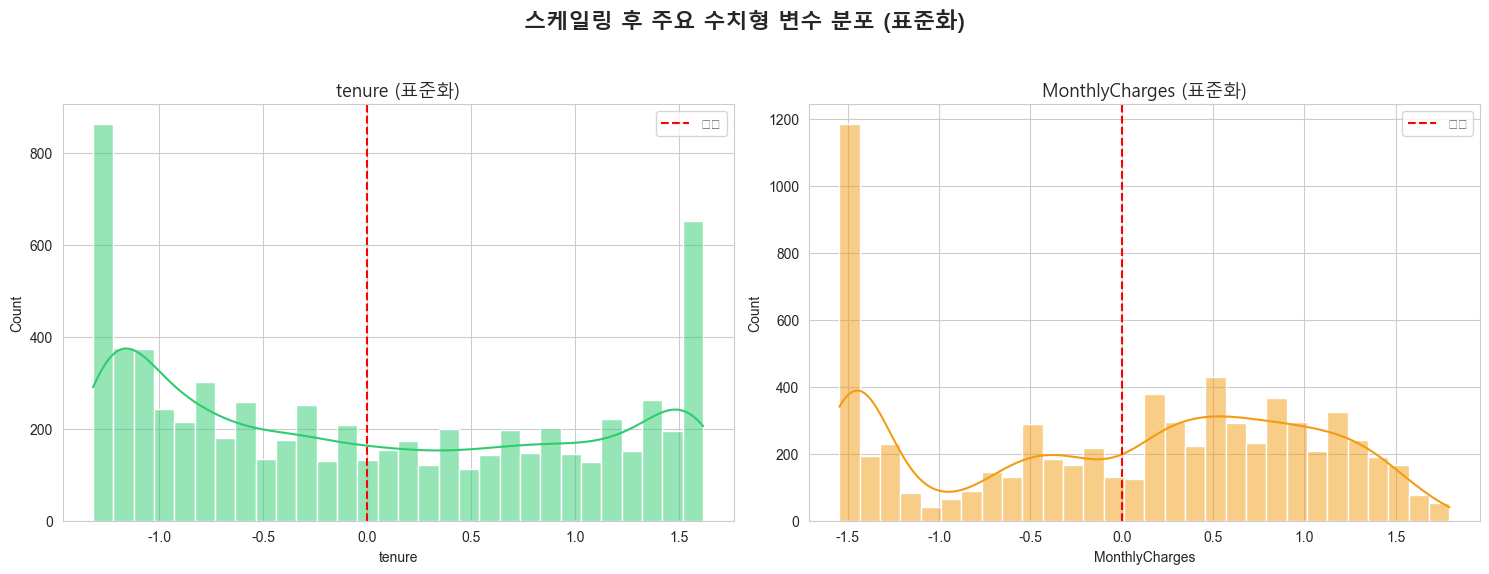

스케일링 후 두 변수 모두 평균이 0에 가까워졌음을 확인했습니다.


In [11]:
# 2) 주요 수치형 변수 (tenure, MonthlyCharges) 분포 확인
print("\n주요 수치형 변수 분포 시각화 (스케일링 후)")

numeric_cols = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('스케일링 후 주요 수치형 변수 분포 (표준화)', font = 'Malgun Gothic', fontsize=16, fontweight='bold')

# 1. tenure (이용 기간)
sns.histplot(df_processed['tenure'], bins=30, kde=True, ax=axes[0], color='#2ecc71')
axes[0].set_title('tenure (표준화)', font = 'Malgun Gothic', fontsize=13)
axes[0].axvline(df_processed['tenure'].mean(), color='red', linestyle='--', label='평균')
axes[0].legend()

# 2. MonthlyCharges (월 요금)
sns.histplot(df_processed['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='#f39c12')
axes[1].set_title('MonthlyCharges (표준화)', font = 'Malgun Gothic', fontsize=13)
axes[1].axvline(df_processed['MonthlyCharges'].mean(), color='red', linestyle='--', label='평균')
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 타이틀 공간 확보
plt.show()
print("스케일링 후 두 변수 모두 평균이 0에 가까워졌음을 확인했습니다.")



주요 범주형 변수와 Churn 관계 시각화


C:\Users\human-18\AppData\Local\Temp\ipykernel_984\3428709116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_contract = sns.barplot(


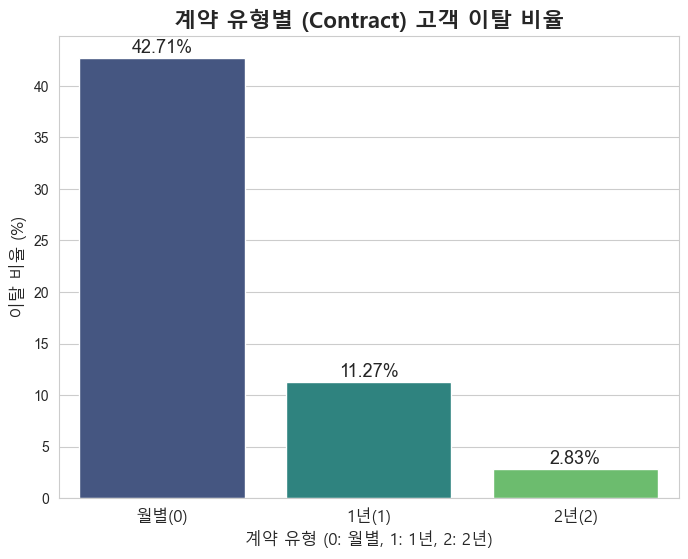

계약 유형별 이탈 비율을 확인했습니다. 월별 계약 고객의 이탈률이 가장 높음을 알 수 있습니다.


In [12]:
# 3) 주요 범주형 변수와 Churn 관계 시각화
print("\n주요 범주형 변수와 Churn 관계 시각화")

# Contract와 InternetService의 이탈 비율을 비교하는 시각화

contract_churn = df_processed.groupby('Contract')['Churn'].mean() * 100

plt.figure(figsize=(8, 6))
ax_contract = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values,
    palette='viridis',
    order=[0, 1, 2]
)

plt.title('계약 유형별 (Contract) 고객 이탈 비율', font = 'Malgun Gothic', fontsize=16, fontweight='bold')
plt.xticks([0, 1, 2], ['월별(0)', '1년(1)', '2년(2)'], font = 'Malgun Gothic', fontsize=12)
plt.ylabel('이탈 비율 (%)', font = 'Malgun Gothic', fontsize=12)
plt.xlabel('계약 유형 (0: 월별, 1: 1년, 2: 2년)', font = 'Malgun Gothic', fontsize=12)

# 각 막대 위에 비율 텍스트 추가
for i, p in enumerate(ax_contract.patches):
    height = p.get_height()
    ax_contract.text(p.get_x() + p.get_width() / 2., height + 0.5,
            f'{height:.2f}%',
            ha='center', fontsize=13)

plt.show()
print("계약 유형별 이탈 비율을 확인했습니다. 월별 계약 고객의 이탈률이 가장 높음을 알 수 있습니다.")

In [13]:
# =============================================================================
# 4. 모델 훈련 및 성능 비교
# =============================================================================

# 4.1 훈련 데이터 및 테스트 데이터 분리

# test_size=0.2: 전체 데이터 중 20%를 테스트 데이터로 사용
# random_state=42: 재현성을 위해 고정
# stratify=y: 타겟 변수(y)의 클래스 비율(0:1)을 훈련 및 테스트 세트에서 동일하게 유지

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 40)
print("[1단계: 훈련/테스트 데이터 분리 완료]")
print(f"훈련 데이터 형태 (X_train): {X_train.shape}")
print(f"테스트 데이터 형태 (X_test): {X_test.shape}")
print("=" * 40)

[1단계: 훈련/테스트 데이터 분리 완료]
훈련 데이터 형태 (X_train): (5634, 17)
테스트 데이터 형태 (X_test): (1409, 17)


In [ ]:
# 6가지 모델 정의
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=10), # 이웃 수 10으로 설정
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'), # 과적합 방지를 위해 깊이 제한
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1])), # 불균형 처리를 위한 scale_pos_weight 적용
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

results = {}

print("=" * 40)
print("[2단계: 6개 모델 학습 및 평가]")
print("=" * 40)

for name, model in models.items():
    # 훈련
    model.fit(X_train, y_train)

    # 예측 확률 (ROC AUC 계산용)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC AUC 점수 계산
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # 예측 클래스 (정확도/리포트용)
    y_pred = model.predict(X_test)

    results[name] = {'model': model, 'y_proba': y_proba, 'auc': roc_auc}

    # 주요 지표 (Precision, Recall, F1-Score) 출력
    report = classification_report(y_test, y_pred, output_dict=True)

    precision_churn = report['1']['precision']  # 정밀도 정의
    recall_churn = report['1']['recall']        # 리콜 정의
    f1_churn = report['1']['f1-score']          # F1-Score 정의

    print(f"[{name}]")
    print(f"ROC AUC 점수: {roc_auc:.4f}")
    print(f"정확도 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    
    print(f"이탈(1) Precision: {precision_churn:.4f}, Recall: {recall_churn:.4f}, F1-Score: {f1_churn:.4f}")

print("\n6가지 모델 학습 및 기본 평가 완료.")

[2단계: 6개 모델 학습 및 평가]
[Logistic Regression]
ROC AUC 점수: 0.8370
정확도 (Accuracy): 0.7410
이탈(1) Precision: 0.5077, Recall: 0.7888, F1-Score: 0.6178
[K-Nearest Neighbors]
ROC AUC 점수: 0.8096
정확도 (Accuracy): 0.7757
이탈(1) Precision: 0.6036, Recall: 0.4519, F1-Score: 0.5168
[Decision Tree]
ROC AUC 점수: 0.8340
정확도 (Accuracy): 0.7516
이탈(1) Precision: 0.5214, Recall: 0.7834, F1-Score: 0.6261
[Random Forest]
ROC AUC 점수: 0.8402
정확도 (Accuracy): 0.7573
이탈(1) Precision: 0.5303, Recall: 0.7487, F1-Score: 0.6208
[XGBoost]
ROC AUC 점수: 0.8161
정확도 (Accuracy): 0.7445
이탈(1) Precision: 0.5141, Recall: 0.6818, F1-Score: 0.5862


c:\ydataprofile\.venv\lib\site-packages\xgboost\training.py:199: UserWarning: [17:52:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[SVM]
ROC AUC 점수: 0.7915
정확도 (Accuracy): 0.7928
이탈(1) Precision: 0.6454, Recall: 0.4866, F1-Score: 0.5549

6가지 모델 학습 및 기본 평가 완료.


C:\Users\human-18\AppData\Local\Temp\ipykernel_984\923564771.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


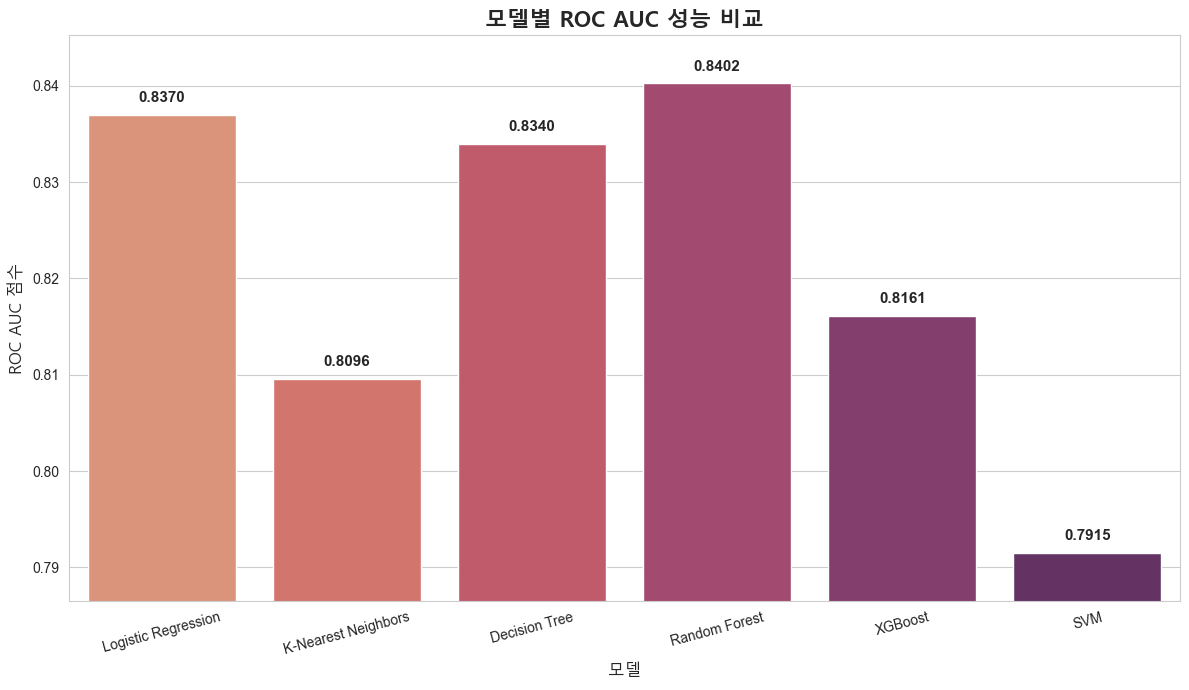

In [15]:
# 6가지 모델의 ROC AUC 데이터를 차트로 출력
sns.set_style("whitegrid")

# ROC AUC 점수를 추출할 딕셔너리 초기화
auc_scores = {}

# results 딕셔너리에서 모델 이름과 AUC 점수 추출
for name, data in results.items():
    auc_scores[name] = data['auc']

# DataFrame으로 변환
df_auc = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'ROC AUC'])

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Model', 
    y='ROC AUC', 
    data=df_auc,
    palette='flare'
)

plt.title('모델별 ROC AUC 성능 비교', font = 'Malgun Gothic', fontsize=16, fontweight='bold')
plt.ylabel('ROC AUC 점수', font = 'Malgun Gothic', fontsize=12)
plt.xlabel('모델', font = 'Malgun Gothic', fontsize=12)
plt.ylim(df_auc['ROC AUC'].min() - 0.005, df_auc['ROC AUC'].max() + 0.005) # Y축 범위 자동 설정

# 각 막대 위에 AUC 값 텍스트 추가
for i, p in enumerate(ax.patches):
    # 정렬된 데이터프레임에서 값을 가져옵니다.
    score = df_auc.loc[i, 'ROC AUC'] 
    ax.text(p.get_x() + p.get_width() / 2., 
            p.get_height() + 0.001,
            f'{score:.4f}', 
            ha='center', 
            va='bottom',
            fontsize=11,
            fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# 5. 최종 모델 훈련
# =============================================================================

# 최적 모델 정의: Random Forest
best_model_name = "Random Forest"

# 5가지 모델 비교 단계에서 사용했던 기본 모델
rf_model_base = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced')

# 튜닝할 하이퍼파라미터 범위 정의(범위 내에서 최적의 조합 찾기)
param_grid = {
    'n_estimators': [100, 200, 300],         # 트리의 개수 (더 복잡한 모델)
    'max_depth': [5, 8, 10],                 # 트리의 최대 깊이 (과적합 방지)
    'min_samples_split': [2, 5, 10]          # 노드를 분할하기 위한 최소 샘플 수
}

print("\n")
print("=" * 40)
print(f"[GridSearchCV: {best_model_name} 하이퍼파라미터 튜닝 시작]")
print("=" * 40)

# GridSearchCV 설정 및 실행
grid_search = GridSearchCV(
        estimator=rf_model_base,
        param_grid=param_grid,
        scoring='roc_auc',  # ROC AUC를 최적화 기준으로 설정
        cv=3,               # 3-겹 교차 검증 사용
        n_jobs=-1,          # 가능한 모든 CPU 코어를 사용하여 속도 향상
        verbose=2           # 진행 상황 출력
    )

# 훈련 데이터(X_train, y_train)를 사용하여 튜닝 실행
grid_search.fit(X_train, y_train)

print("\n GridSearchCV 튜닝 완료")
print("=" * 40)
print(f"최적 ROC AUC 점수 (교차 검증): {grid_search.best_score_:.4f}")
print(f"최적 하이퍼파라미터 조합: {grid_search.best_params_}")

# 최종 모델 성능 평가 및 저장
final_best_model = grid_search.best_estimator_



[GridSearchCV: Random Forest 하이퍼파라미터 튜닝 시작]
Fitting 3 folds for each of 27 candidates, totalling 81 fits

 GridSearchCV 튜닝 완료
최적 ROC AUC 점수 (교차 검증): 0.8450
최적 하이퍼파라미터 조합: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 300}


In [17]:
# 최종 모델 성능을 테스트 데이터(X_test)로 평가
y_pred_final = final_best_model.predict(X_test)
y_proba_final = final_best_model.predict_proba(X_test)[:, 1]

final_auc = roc_auc_score(y_test, y_proba_final)
final_report = classification_report(y_test, y_pred_final, output_dict=True)

# 지표 재정의 및 출력
final_precision_churn = final_report['1']['precision']
final_recall_churn = final_report['1']['recall']
final_f1_churn = final_report['1']['f1-score']

print("\n")
print("=" * 40)
print(f"[{best_model_name} - 최종 튜닝 모델 테스트 결과]")
print("=" * 40)
print(f"테스트 ROC AUC: {final_auc:.4f}")
print(f"이탈(1) 정밀도: {final_precision_churn:.4f}")
print(f"이탈(1) 리콜: {final_recall_churn:.4f}")
print(f"이탈(1) F1-Score: {final_f1_churn:.4f}")

# 최종 모델 저장
with open('model/final_best_churn_model.pkl', 'wb') as file:
    pickle.dump(final_best_model, file)
print(f"\n 최종 최적화 모델이 'final_best_churn_model.pkl'로 저장되었습니다. (성능: ROC AUC {final_auc:.4f})")



[Random Forest - 최종 튜닝 모델 테스트 결과]
테스트 ROC AUC: 0.8412
이탈(1) 정밀도: 0.5366
이탈(1) 리콜: 0.7647
이탈(1) F1-Score: 0.6307

 최종 최적화 모델이 'final_best_churn_model.pkl'로 저장되었습니다. (성능: ROC AUC 0.8412)


C:\Users\human-18\AppData\Local\Temp\ipykernel_984\2171754936.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


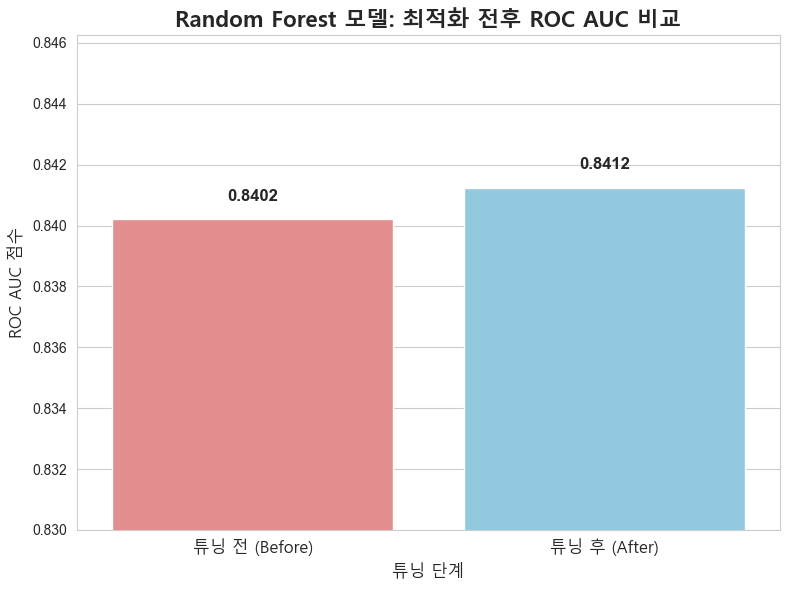

In [18]:
auc_before = 0.8402 # 튜닝 전 기본 모델 AUC 값
auc_after = final_auc

comparison_data = {
    '단계': ['튜닝 전 (Before)', '튜닝 후 (After)'],
    'ROC AUC': [auc_before, auc_after]
}
df_comparison = pd.DataFrame(comparison_data)

# 시각화
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x='단계', 
    y='ROC AUC', 
    data=df_comparison,
    palette=['lightcoral', 'skyblue']
)

# Y축 범위 조정 (최소값을 데이터 값에 가깝게 설정하여 차이 비교)
min_val = min(auc_before, auc_after)
plt.ylim(0.83, auc_after + 0.005) # 최소값을 0.83로 설정

# 폰트 및 제목 설정
plt.title('Random Forest 모델: 최적화 전후 ROC AUC 비교', 
          font = 'Malgun Gothic', fontsize=16, fontweight='bold')
plt.ylabel('ROC AUC 점수', font = 'Malgun Gothic', fontsize=12)
plt.xlabel('튜닝 단계', font = 'Malgun Gothic', fontsize=12)

# X축 눈금 라벨 폰트 설정 (한글 깨짐 방지)
plt.xticks(
    ticks=ax.get_xticks(), 
    labels=ax.get_xticklabels(), 
    fontproperties={'family': 'Malgun Gothic', 'size': 12}
)

# 막대 위에 AUC 값 텍스트 추가
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.0005,
            f'{p.get_height():.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

c:\ydataprofile\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ydataprofile\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ydataprofile\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ydataprofile\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ydataprofile\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ydataprofile\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ydataprofile\.venv\lib\site-packages\se

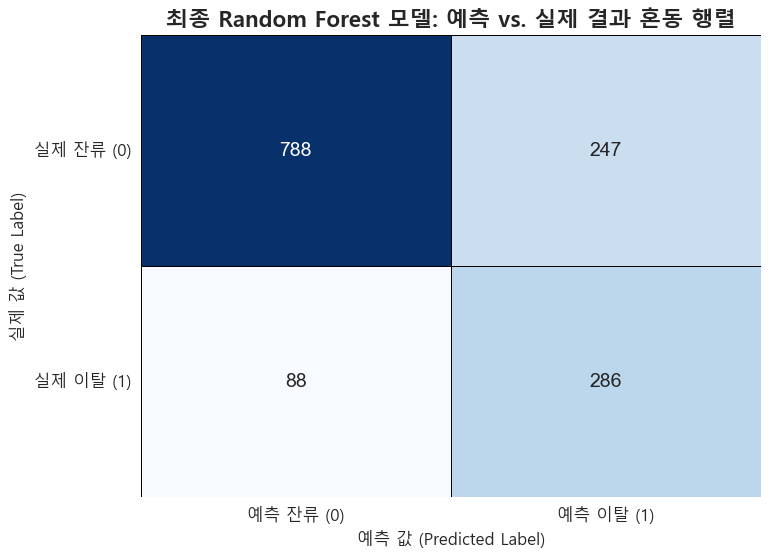

In [19]:
# 혼동 행렬 데이터 계산

cm = confusion_matrix(y_test, y_pred_final)

# 데이터프레임으로 변환하여 시각화 레이블 정의
cm_df = pd.DataFrame(cm, 
                     index=['실제 잔류 (0)', '실제 이탈 (1)'], 
                     columns=['예측 잔류 (0)', '예측 이탈 (1)'])

# 시각화
plt.figure(figsize=(8, 6))
# 시각화 (annot=True로 셀 안에 숫자 표시, fmt='d'로 정수 표시)
ax_cm = sns.heatmap(cm_df, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            cbar=False,
            linewidths=0.5,
            linecolor='black',
            annot_kws={"size": 14}) 

# 폰트 및 제목 설정
plt.title('최종 Random Forest 모델: 예측 vs. 실제 결과 혼동 행렬', 
          font = 'Malgun Gothic', fontsize=16, fontweight='bold')
plt.ylabel('실제 값 (True Label)', 
           font = 'Malgun Gothic', fontsize=12)
plt.xlabel('예측 값 (Predicted Label)', 
           font = 'Malgun Gothic', fontsize=12)

# 축 눈금 폰트 설정 (한글 깨짐 방지)
ax_cm.tick_params(axis='x', labelsize=12)
ax_cm.tick_params(axis='y', labelsize=12, rotation=0)

for label in ax_cm.get_xticklabels():
    label.set_fontproperties({'family': 'Malgun Gothic', 'size': 12})
for label in ax_cm.get_yticklabels():
    label.set_fontproperties({'family': 'Malgun Gothic', 'size': 12})

plt.show()

In [20]:
# =============================================================================
# 6. 임의의 고객 데이터 생성 및 예측
# =============================================================================

# 저장된 모델과 Scaler 로드
with open('model/final_best_churn_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('model/scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

# 전처리 함수 (원본 값 → 모델 입력 형식)
def preprocess_customer_data(customer_info, scaler):
    """
    원본 고객 데이터를 모델 입력 형식으로 전처리
    
    Parameters:
    -----------
    customer_info : dict
        원본 고객 정보 (tenure=12, MonthlyCharges=70 등)
    scaler : StandardScaler
        훈련 시 사용한 scaler 객체
    
    Returns:
    --------
    pd.DataFrame : 전처리된 데이터프레임
    """
    
    # 1. 수치형 변수 스케일링
    numeric_features = np.array([[
        customer_info['tenure'], 
        customer_info['MonthlyCharges']
    ]])
    scaled_numeric = scaler.transform(numeric_features)
    
    # 2. 범주형 변수 인코딩
    # Contract 매핑
    contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    contract_encoded = contract_map[customer_info['Contract']]
    
    # 이진 변수 매핑 (Yes/No → 1/0)
    binary_map = {'Yes': 1, 'No': 0}
    
    # 3. 전처리된 데이터 구성 (모델이 기대하는 정확한 순서!)
    # 순서: tenure, MonthlyCharges, OnlineSecurity, OnlineBackup, DeviceProtection,
    #       StreamingTV, StreamingMovies, SeniorCitizen, Partner, Dependents,
    #       Contract, PaperlessBilling, InternetService_Fiber optic, InternetService_No,
    #       PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check
    
    processed = pd.DataFrame([{
        'tenure': scaled_numeric[0][0],
        'MonthlyCharges': scaled_numeric[0][1],
        'OnlineSecurity': binary_map[customer_info['OnlineSecurity']],
        'OnlineBackup': binary_map[customer_info['OnlineBackup']],
        'DeviceProtection': binary_map[customer_info['DeviceProtection']],
        'StreamingTV': binary_map[customer_info['StreamingTV']],
        'StreamingMovies': binary_map[customer_info['StreamingMovies']],
        'SeniorCitizen': customer_info['SeniorCitizen'],
        'Partner': binary_map[customer_info['Partner']],
        'Dependents': binary_map[customer_info['Dependents']],
        'Contract': contract_encoded,
        'PaperlessBilling': binary_map[customer_info['PaperlessBilling']],
        'InternetService_Fiber optic': 1 if customer_info['InternetService'] == 'Fiber optic' else 0,
        'InternetService_No': 1 if customer_info['InternetService'] == 'No' else 0,
        'PaymentMethod_Credit card (automatic)': 1 if customer_info['PaymentMethod'] == 'Credit card (automatic)' else 0,
        'PaymentMethod_Electronic check': 1 if customer_info['PaymentMethod'] == 'Electronic check' else 0,
        'PaymentMethod_Mailed check': 1 if customer_info['PaymentMethod'] == 'Mailed check' else 0
    }])
    
    return processed

# 예측 함수
def predict_churn(customer_info, model, scaler):
    """
    고객 이탈 예측
    
    Parameters:
    -----------
    customer_info : dict
        원본 고객 정보
    model : 학습된 모델
    scaler : StandardScaler
    
    Returns:
    --------
    dict : 예측 결과
    """
    # 전처리
    processed_data = preprocess_customer_data(customer_info, scaler)
    
    # 예측
    prediction = model.predict(processed_data)[0]
    probabilities = model.predict_proba(processed_data)[0]
    
    return {
        '예측': '이탈' if prediction == 1 else '잔류',
        '잔류_확률': probabilities[0],
        '이탈_확률': probabilities[1],
        '위험도': '높음' if probabilities[1] > 0.7 else '중간' if probabilities[1] > 0.4 else '낮음'
    }

# 랜덤 고객 데이터 생성 함수
def generate_random_customer():
    """랜덤한 고객 데이터 생성"""
    return {
        'tenure': np.random.randint(1, 72),
        'MonthlyCharges': np.random.uniform(18.0, 118.0),
        'SeniorCitizen': np.random.choice([0, 1]),
        'Partner': np.random.choice(['Yes', 'No']),
        'Dependents': np.random.choice(['Yes', 'No']),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No']),
        'OnlineSecurity': np.random.choice(['Yes', 'No']),
        'OnlineBackup': np.random.choice(['Yes', 'No']),
        'DeviceProtection': np.random.choice(['Yes', 'No']),
        'StreamingTV': np.random.choice(['Yes', 'No']),
        'StreamingMovies': np.random.choice(['Yes', 'No']),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year']),
        'PaperlessBilling': np.random.choice(['Yes', 'No']),
        'PaymentMethod': np.random.choice([
            'Bank transfer (automatic)',
            'Credit card (automatic)',
            'Electronic check',
            'Mailed check'
        ])
    }


print("\n" + "=" * 40)
print("[테스트: 랜덤 생성 고객 5명]")
print("=" * 40)

# 5명의 랜덤 고객 생성 및 예측
results_list = []

for i in range(5):
    # 랜덤 고객 생성
    random_customer = generate_random_customer()

    # 예측
    result = predict_churn(random_customer, loaded_model, loaded_scaler)
    
    # 결과 저장
    results_list.append({
        '고객번호': f'고객 {i+1}',
        '계약기간': f"{random_customer['tenure']}개월",
        '월요금': f"${random_customer['MonthlyCharges']:.2f}",
        '계약유형': random_customer['Contract'],
        '인터넷': random_customer['InternetService'],
        '예측': result['예측'],
        '이탈확률': f"{result['이탈_확률']:.1%}",
        '위험도': result['위험도']
    })

# 결과를 DataFrame으로 표시
results_df = pd.DataFrame(results_list)
print("\n")
print(results_df.to_string(index=False))


[테스트: 랜덤 생성 고객 5명]


c:\ydataprofile\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\ydataprofile\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\ydataprofile\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\ydataprofile\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\ydataprofile\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(




고객번호 계약기간     월요금           계약유형         인터넷 예측  이탈확률 위험도
고객 1 65개월 $116.43       One year Fiber optic 잔류 41.1%  중간
고객 2 11개월  $78.47       Two year          No 잔류  9.7%  낮음
고객 3 35개월  $62.69 Month-to-month Fiber optic 잔류 38.8%  낮음
고객 4 23개월 $116.08       One year          No 잔류 18.0%  낮음
고객 5  4개월  $20.82       One year Fiber optic 잔류 27.6%  낮음
